In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
def t_acc(a,s,mx,rho_x,T):
    """
    Input:
    a : grain radius [micron]
    s : grain material density [g cm^-3]
    mx : mass of accreting species [amu]
    rho_x : gas mass density of accreting species [g cm^-3]
    T : gas temperature [K]
    Output:
    t : accretion timescale [s]
    """
    amu = 1.66053906660e-24 # g
    mH = 1.6735575e-24 # g
    t_acc = 0.3682612 * (a/0.005) * (s/3.) * np.sqrt(mx) * (mH / rho_x) * (50./T)**0.5  # Myr
    t = t_acc * 365 * 24 * 3600 * 1e6  # s
    return t

def Nc2a(Nc):
    """
    Input:
    Nc : number of carbon atoms in PAH
    Output:
    a : PAH radius [micron]
    """
    a = 10 * (Nc/418)**(1./3.) # in Angstrom
    return a * 1e-4 # in micron

In [4]:
# Example calculation
amu = 1.66e-24 # g
Nc = np.array([54,418])
a = Nc2a(Nc)
s = 2 # g cm^-3 for PAHs
mx = 12.0 # amu for carbon
nH = 1e4 # cm^-3
mH = 1.6735575e-24 # g
xC = 1.4e-4 # carbon abundance
n_C = xC * nH # cm^-3
rho_x = n_C * mx * amu # g cm^-3
T = 100.0 # K
t_acc_values = t_acc(a,s,mx,rho_x,T)
print(t_acc_values,a)
print(n_C * mx * amu, rho_x)
for i in range(len(Nc)):
    print(f"Nc = {Nc[i]:.0f}, a = {a[i]*1e4:.2f} Angstrom, t_acc = {t_acc_values[i]/(365*24*3600*1e6):.6f} Myr")

[1.15063972e+11 2.27614645e+11] [0.00050552 0.001     ]
2.7887999999999995e-23 2.7887999999999995e-23
Nc = 54, a = 5.06 Angstrom, t_acc = 0.003649 Myr
Nc = 418, a = 10.00 Angstrom, t_acc = 0.007218 Myr


In [5]:
def Langevin_rate(Nc,mx):
    """
    Input:
    Nc : number of carbon atoms in PAH
    mx : mass of colliding species [amu]
    Output:
    k_L : Langevin rate coefficient [cm^3 s^-1]
    """
    k_L = 6e-9 * np.sqrt(Nc/50.) * np.sqrt(12./mx)
    return k_L

0.0005055209509834891
0.001


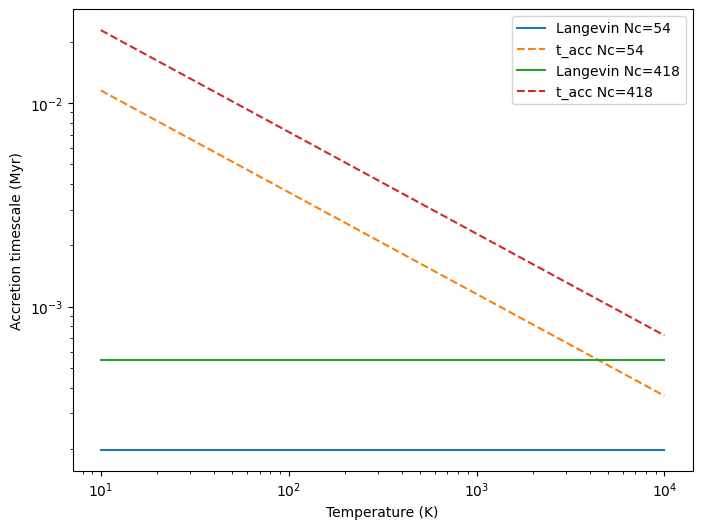

In [14]:
fig, ax = plt.subplots(figsize=(8,6))
T = np.logspace(1,4,100) # K
Nc_values = [54, 418]
mx = 12.0 # amu for carbon
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Accretion timescale (Myr)")
for Nc in Nc_values:
    mgrain = 4./3. * np.pi * (Nc2a(Nc)*1e-4)**3 * s # g
    k_L = Langevin_rate(Nc,mx) * np.ones_like(T)
    t_L = mgrain/(k_L*rho_x) / (365*24*3600*1e6) # convert s to Myr
    ax.plot(T, t_L , label=f"Langevin Nc={Nc}")
    print(Nc2a(Nc))
    t_acc_vals = t_acc(Nc2a(Nc),s,mx,rho_x,T)/(365*24*3600*1e6) # convert s to Myr
    ax.plot(T, t_acc_vals, linestyle='--', label=f"t_acc Nc={Nc}")
ax.legend()

In [7]:
mH = 1.6735575e-24 # g
t_acc(0.0005,3,1,mH,50)/(365*24*3600*1e6)  # convert s to Myr

0.03682612000000001

In [8]:
kb = 1.380649e-16 # erg K^-1
amu = 1.66053906660e-24 # g


In [9]:
(np.pi/(8.*kb))**0.5 * 4./3. * 0.005*1e-4 * 3 * np.sqrt(amu)/(np.sqrt(50)*amu) /(365*24*3600*1e6)  # convert s to Myr

0.37119501855105325

In [10]:
Langevin_rate(14,12)

3.174901573277509e-09